In [1]:
"""
water_mass_transport.py
author: Tahya Weiss-Gibbons (adapted by Grace Kirkpatrick)

Calculate the transport across a straight line section of a water mass
Gives volume, heat, freshwater and salt transport of the water mass

**IMPORTANT** 
This program calculates volume transport for a NEMO run where output temperature and salinity were calculated with respect to EOS80 rather
than the more recent TEOS10. However, as per the recommendations of McDougall et. al (2021), the output variable of NEMO is assumed to
be thermodynamically consistent with the definition of Conservative Temperature and its salinity output with Preformed Salinity / u_p. 
Calculations of density are therefore made with the gsw toolbox rather than the obsolete seawater package. 

"""

import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

import datetime
import cftime
import time

import gsw

In [2]:
#gets the list of grid points for a straight section between two points
#uses the bresenham line algorithm
def plotLineLow(x0, x1, y0, y1):
    ii, jj = [], []
    dx, dy = x1 -x0, y1 - y0    
    
    yi, y, D = 1, y0, (2*dy) - dx
    
    if dy < 0:
        yi = -1
        dy = -dy

    for x in range(x0, x1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            y = y+yi
            D = D+(2*(dy-dx))
            ii.append(x)
            jj.append(y)
        else:
            D = D+2*dy
    return ii, jj

def plotLineHigh(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 - x0
    dy = y1 - y0
    
    xi = 1
    if dx < 0:
        xi = -1
        dx = -dx
    D = (2*dx) - dy
    x = x0

    for y in range(y0, y1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            x = x+xi
            D = D + (2*(dx-dy))
            ii.append(x)
            jj.append(y)
        else:
            D = D + 2*dx
    return ii, jj

def section_calculation(x0, x1, y0, y1):
    
    if abs(y1-y0) < abs(x1-x0):
        if x0 > x1:
            ii, jj = plotLineLow(x1, x0, y1, y0)
        else:
            ii, jj = plotLineLow(x0, x1, y0, y1)
    else:
            if y0 > y1:
                ii, jj = plotLineHigh(x1, x0, y1, y0)
            else:
                ii, jj = plotLineHigh(x0, x1, y0, y1)
    return ii, jj
    
#then shifts ii jj indices (whole dataset indices) to subset indices 
def shift_subset_bounds(ii, jj):
    ii = [x - ii[0] for x in ii]
    jj = [x - jj[0] for x in jj]
    return ii, jj

In [3]:
def time_bounds(startyear, startmonth, startday, endyear, endmonth, endday):
    return [startyear, startmonth, startday, endyear, endmonth, endday]

def space_bounds(n1, n2, n3, n4):
    return [n1, n2, n3, n4]

def get_times(dates):
    start_time = datetime.date(dates[0], dates[1], dates[2])
    end_time = datetime.date(dates[3], dates[4], dates[5])

    #figure out all the dates we have model files
    delta = end_time - start_time
    times = []

    i = 0
    while i < delta.days+1:
        t = start_time + datetime.timedelta(days=i)
        if t.month == 2 and t.day == 29:
            t = datetime.date(t.year, 3, 1)
            i = i+6
        else:
            i = i+5
        times.append(t)

    return times

In [4]:
def preprocess_v(ds): 
    ds = ds[['vomecrty', 'e3v']]
    if inds[0]==inds[1]: ds = ds.sel(x = inds[0])
    else: ds = ds.sel(x=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y = inds[3])
    else: ds = ds.sel(y=slice(inds[2], inds[3]))  
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_u(ds): 
    ds = ds[['vozocrtx', 'e3u']]
    if inds[0]==inds[1]: ds = ds.sel(x = inds[0])
    else: ds = ds.sel(x=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y = inds[3])
    else: ds = ds.sel(y=slice(inds[2], inds[3]))  
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_t(ds): 
    ds = ds[['vosaline', 'votemper']]
    ds = ds.sel(x_grid_T=slice(inds[0],inds[1]+ 1))
    ds = ds.sel(y_grid_T=slice(inds[2],inds[3]+ 1))                       
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_mask(ds): # mask is on t-grid! but variables are not named the same
    ds = ds[['e1u','e2v', 'umask', 'vmask']] # we want u and v vars now

    if inds[0]==inds[1]: ds = ds.sel(x = inds[0])
    else: ds = ds.sel(x=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y = inds[3])
    else: ds = ds.sel(y=slice(inds[2], inds[3]))                         
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all
    
def get_files(path, dpath, runid, times, inds):
    #need both the u and v components of velocity
    inds = inds
    mdl_files_v = []
    mdl_files_u = []
    mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")

    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_v)
    du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_u)
    dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
    mask = xr.open_mfdataset(dpath+'ANHA4_mesh_mask.nc', preprocess=preprocess_mask)

    return dv, du, dt, mask
    

In [5]:
def create_output_file(write_path, runid, secname, dates, var_u, var_v): 
    
    var_names = [['u_vel', 'utemp', 'usala', 'urho', 'e3u', 'umask', 'e1u'], ['v_vel', 'vtemp', 'vsala', 'vrho', 'e3v', 'vmask', 'e2v']]
    climvars = [var_u, var_v]

    dim_labels = [['nav_lat_u', 'nav_lon_u'], ['nav_lat_v', 'nav_lon_v']]
    cldims = [var_u[0], var_v[0]]
    
    ncfile = Dataset(write_path[2] + runid + '_'+ secname +'_'+ str(dates[0])+'-'+str(dates[3]) + '.nc', mode='w',format='NETCDF4') 
    
    ncfile.createDimension('time_counter', None)
    ncfile.createDimension('depth', var_u[0].depthu.shape[0]) # add some kind of exception for when the shape for each is 1d

    time_counter = ncfile.createVariable('time_counter', int, ('time_counter',))
    depth = ncfile.createVariable('depth', float, ('depth',))
    
    time_counter[:] = cftime.date2num(var_u[0]['time_counter'][:], 'seconds since 1900-01-01 00:00:00', calendar = 'noleap')
    #time_counter[:] = cftime.num2date(time_counter[:], 'seconds since 1900-01-01 00:00:00', calendar = 'noleap')
    depth[:] = cldims[0]['depthu'][:]

    for x in range(len(cldims)):
        ncfile.createDimension(dim_labels[x][0], cldims[x].nav_lat.shape[0])
        ncfile.createDimension(dim_labels[x][1], cldims[x].nav_lon.shape[1])
        
        lat = ncfile.createVariable(dim_labels[x][0], float, (dim_labels[x][0], dim_labels[x][1]))
        lon = ncfile.createVariable(dim_labels[x][1], float, (dim_labels[x][0], dim_labels[x][1]))

        lat[:] = cldims[x]['nav_lat'][:,:]
        lon[:] = cldims[x]['nav_lon'][:,:]

    for x in range(len(climvars)):
        for y in range(len(var_names[0])):
            if y < 5:
                z = ncfile.createVariable(var_names[x][y], float, ('time_counter', 'depth', dim_labels[x][0], dim_labels[x][1]))
            elif y == 5:
                z = ncfile.createVariable(var_names[x][y], float, ('depth', dim_labels[x][0], dim_labels[x][1]))
            elif y == 6: 
                z = ncfile.createVariable(var_names[x][y], float, (dim_labels[x][0], dim_labels[x][1]))
            print(y)
            z[:] = climvars[x][y][:]

    ncfile.close()
    
def get_rho_ct_asal(dt): # get rho, temp, abs sal on t grid
    ps = dt['vosaline'][:,:,-1,-1] * (35.16504/35) # converting to preformed salinity
    asal = gsw.SA_from_Sstar(ps, 10.1325, dt.nav_lon_grid_T, dt.nav_lat_grid_T) # get asal from preformed
    ct = dt['votemper'][:,:,-1,-1] # getting rid of edges used to change to u and v
    rho = gsw.sigma0(asal, ct)
    
    return rho, ct, asal

def define_paths(model_output_path, model_data_path, netcdf_write_path):
    return [model_output_path, model_data_path, netcdf_write_path]

is it faster to subset these datasets or does the additional overhead actually make it slower? or rather how much slower, bc i think using the gibbs formulas at every timestep rather than accessing density directly would be very slow indeed. 33 secs without subsetting; 99 for all three vars; *3 for all years for 5 minutes; 22 secs with subsetting; 66 for all three; 3.3 mins

In [6]:
def transport_calculations(paths, runid, secname, inds, dates):

    #fresh_ref = gsw.SA_from_Sstar(f['psal'] * (35.16504/35), 10.1325, 54, 53) # characteristic lat/lon of your fw (mine in LC)
    
    #get list of times in the dataset from the start date (YYYYMMDD) and end date (YYYYMMDD)
    times = get_times(dates)
    
    #load in dataset (u, v, t grids)
    dv, du, dt, mask = get_files(paths[0], paths[1], runid, times, inds)

    dv = dv.resample(time_counter='M').mean().compute()
    du = du.resample(time_counter='M').mean().compute()
    dt = dt.resample(time_counter='M').mean().compute()

    print(dv['vomecrty'].shape)
    print('done loading')

    #read in the mask file
    e1u = mask['e1u'][0,:,:].compute() # i thickness
    e3u = np.where(mask['umask'][0,:,:,:], du['e3u'][:,:,:,:], np.nan) # k thickness

    e2v = mask['e2v'][0,:,:].compute() # j thickness
    e3v = np.where(mask['vmask'][0,:,:,:], dv['e3v'][:,:,:,:], np.nan) # k thickness

    print(e1u.shape)
    print(e2v.shape)
    print(e3u.shape)
    print(e3v.shape)
    
    #now we need to get temperature and salinity on the u & v-grids by averaging t_i and t_(i+1), s_i and s_(i+1)
    
    t_u = (dt['votemper'][:,:, :, :-1] /2 + dt['votemper'][:,:, :, 1:] /2)[:,:,:-1,:].compute() #model output temperature (u)
    t_v = (dt['votemper'][:,:, :-1, :] /2 + dt['votemper'][:,:, 1:, :] /2)[:,:,:,:-1].compute() #model output temperature (v)

    s_u = (dt['vosaline'][:,:, :, :-1] /2 + dt['vosaline'][:,:, :, 1:] /2)[:,:,:-1,:].compute() #model output salinity (u)
    s_v = (dt['vosaline'][:,:, :-1, :] /2 + dt['vosaline'][:,:, 1:, :] /2)[:,:,:,:-1].compute() #model output salinity (v)

    sa_u = gsw.SA_from_Sstar(s_u * (35.16504/35), 10.1325, du.nav_lon, du.nav_lat).compute() #absolute salinity
    sa_v = gsw.SA_from_Sstar(s_v * (35.16504/35), 10.1325, dv.nav_lon, dv.nav_lat).compute() #absolute salinity

    rho_u = gsw.sigma0(sa_u, t_u).compute()
    rho_v = gsw.sigma0(sa_v, t_v).compute()

    u = du['vozocrtx'][:] 
    v = dv['vomecrty'][:]

    print(t_u.shape)
    print(t_v.shape)
    print(s_u.shape)
    print(s_v.shape)
    print(sa_u.shape)
    print(sa_v.shape)
    print(rho_u.shape)

    print('done u/v gridding')

    #Define the transect and get the iijj list. The Bresenham Line Algorithm doesnt't know about python's ending-exclusing indexing, so we 
    #need to subtract one from our grid i-j index values to avoid getting an out-of-bounds error. 
    
    iit, jjt = section_calculation(inds[0], inds[1]-1, inds[2], inds[3]-1) # temporary indices in full-output i/j coordinates
    ii, jj = shift_subset_bounds(iit, jjt) # indices shifted to subset i/j coordinates FIX

    mask_u = np.zeros(mask['umask'][0,:,:,:].shape)
    mask_v = np.zeros(mask['umask'][0,:,:,:].shape)

    for n in range(len(ii)-1): #only change in x OR y, not both
        j1, j2, i1, i2 = jj[n], jj[n+1], ii[n], ii[n+1]

        if j1 == j2: #that is, if getting to the next point requires change in x only
            mask_v[:, jj[n], ii[n]] += 1 # we want the vertical velocity
        else:
            mask_u[:, jj[n], ii[n]] += 1 # we want the horizontal velocity
                
    mask_u = mask_u.astype(bool)
    mask_v = mask_v.astype(bool)

    out_ulist = [u, t_u, sa_u, rho_u, e3u, mask_u, e1u]
    out_vlist = [v, t_v, sa_v, rho_v, e3v, mask_v, e2v]

    create_output_file(paths, runid, secname, dates, out_ulist, out_vlist)

    dt.close()
    du.close()
    dv.close()
    mask.close()

done loading
done t gridding
(10, 30) lat
(10, 30) lon
(50,) dep
(74,) time 
(10, 30, 50, 74, 50) -> should be 74, 50, 10, 30
u_trans

In [55]:
if __name__ == "__main__":
    dates = time_bounds(2004, 1, 5, 2005, 1, 5)
    inds = space_bounds(55+125, 85+125, 85+225, 95+225)
    paths = ["/mnt/storage6/myers/NEMO/ANHA4-EPM151/", '/mnt/storage4/grace/grace/data/model_masks/', '/mnt/storage4/grace/grace/data/transport_outputs/ANHA4/']
    tic = time.time()
    transport_calculations(paths, 'EPM151', 'preGB', inds, dates)
    toc = time.time()
    print(toc-tic)

KeyboardInterrupt: 

In [7]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridT.nc")
ds_u4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m12d31_gridU.nc")
ds_v4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridV.nc")
import matplotlib.colors as colors
mask = np.zeros((10,10))
py = [0,1,2,3,4,5,6,7,8,9]
px = [0,1,2,3,4,5,6,7,8,9]

In [29]:
sa_u = gsw.SA_from_Sstar(ds_t4['vosaline'][:] * (35.16504/35), 10.1325, ds_t4.nav_lon_grid_T, ds_t4.nav_lat_grid_T)
s_ref = gsw.SA_from_Sstar(ds_t4['vosaline'][:], 10.1325, ds_t4.nav_lon_grid_T, ds_t4.nav_lat_grid_T)
t_u = ds_t4['votemper'][:]
rho_psal = gsw.sigma0(ds_t4['vosaline'][:], t_u[:]) # density derived from model output salinity + model output temp
rho_asal = gsw.sigma0(sa_u, t_u)
rho_ref = gsw.sigma0(s_ref, t_u)

In [24]:
dt = np.where(ds_t4['vosaline'][:] != 0, ds_t4['vosaline'][:], np.nan)

In [25]:
rho_p = np.where(rho_psal[:] > 0, rho_psal[:], np.nan)

In [32]:
rho_a = np.where(rho_asal[:] > 0, rho_asal[:], np.nan)

Text(0.5, 1.0, 'Rho(abs_sal) - Rho(prac_sal) @ 2000m, kg/m3')

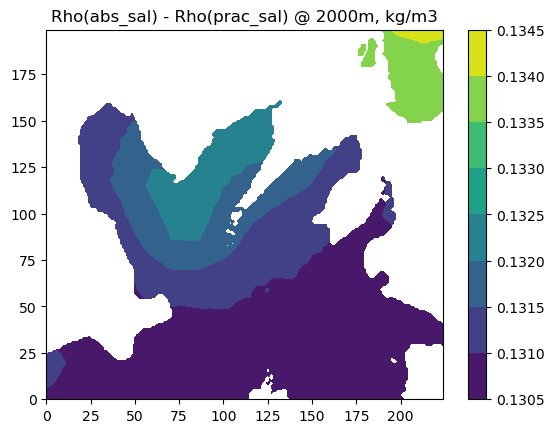

In [58]:
plt.contourf(rho_a[0,39,250:450, 150:375]-rho_p[0,39,250:450, 150:375])
plt.colorbar()
plt.title('Rho(abs_sal) - Rho(prac_sal) @ 2000m, kg/m3')

Text(0.5, 1.0, 'Rho(abs_sal) - Rho(prac_sal) @ 1000m, kg/m3')

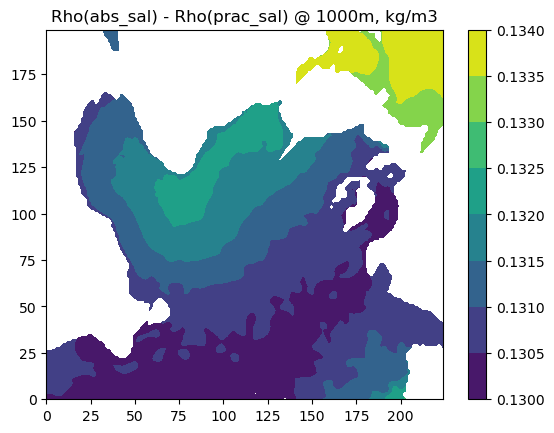

In [53]:
plt.contourf(rho_a[0,35,250:450, 150:375]-rho_p[0,35,250:450, 150:375])
plt.colorbar()
plt.title('Rho(abs_sal) - Rho(prac_sal) @ 1000m, kg/m3')

Text(0.5, 1.0, 'Rho(abs_sal) - Rho(prac_sal) @ 500m, kg/m3')

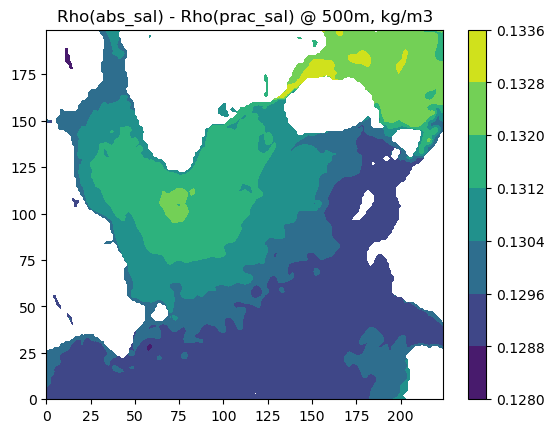

In [54]:
plt.contourf(rho_a[0,30,250:450, 150:375]-rho_p[0,30,250:450, 150:375])
plt.colorbar()
plt.title('Rho(abs_sal) - Rho(prac_sal) @ 500m, kg/m3')

Text(0.5, 1.0, 'Rho(abs_sal) - Rho(prac_sal) @ 0m, kg/m3')

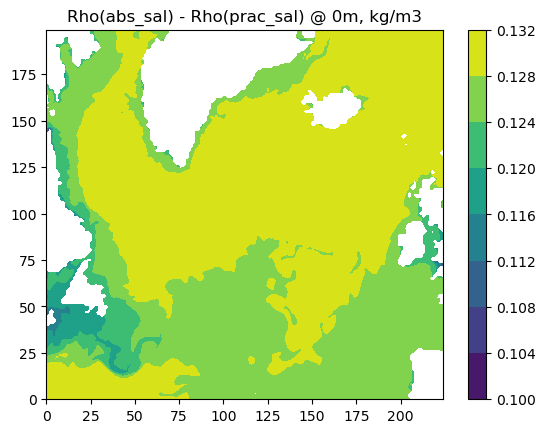

In [59]:
plt.contourf(rho_a[0,0,250:450, 150:375]-rho_p[0,0,250:450, 150:375])
plt.colorbar()
plt.title('Rho(abs_sal) - Rho(prac_sal) @ 0m, kg/m3')

In [56]:
ds_v4.depthv.values[39]

1941.8934

In [11]:
ds_u4

<xarray.Dataset>
Dimensions:               (y: 800, x: 544, depthu: 50, axis_nbounds: 2,
                           time_counter: 1)
Coordinates:
    nav_lat               (y, x) float32 dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lon               (y, x) float32 dask.array<chunksize=(800, 544), meta=np.ndarray>
  * depthu                (depthu) float32 0.494 1.541 ... 5.275e+03 5.728e+03
    time_centered         (time_counter) object dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) object 2019-05-23 12:00:00
Dimensions without coordinates: y, x, axis_nbounds
Data variables:
    depthu_bounds         (depthu, axis_nbounds) float32 dask.array<chunksize=(50, 2), meta=np.ndarray>
    vozocrtx              (time_counter, depthu, y, x) float32 dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) object dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) object dask.array<chunksize=(1, 2), meta=np.ndarray>
    sozotaux              (time_counter, y, x) float32 dask.array<chunksize=(1, 800, 544), meta=np.ndarray>
    e3u                   (time_counter, depthu, y, x) float32 dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
Attributes:
    name:         ANHA4-EPM151
    description:  ocean U grid variables
    title:        ocean U grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Dec-04 20:16:19 EST

In [19]:
l = np.stack([ds_t4['vosaline'][0,0,:,:].values] * 50)

In [19]:
def get_files_test(path, runid, times, inds):
    #need both the u and v components of velocity
    inds = inds
    mdl_files_v = []
    #mdl_files_u = []
    #mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        #mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        #mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")

    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_v)
    #du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_u)
    #dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
    #mask = xr.open_mfdataset(dpath+'ANHA4_mesh_mask.nc', preprocess=preprocess_mask)

    return dv#, du, dt, mask

In [20]:
dates = time_bounds(2004, 1, 5, 2005, 1, 5)
inds = space_bounds(55+125, 85+125, 85+225, 95+225) # something off with ii & jj- figure it out!!!
inddates = get_times(dates)
m = get_files_test("/mnt/storage6/myers/NEMO/ANHA4-EPM151/", 'EPM151', inddates, inds) 

In [27]:
p = m.resample(time_counter='M').mean()

In [28]:
p.time_counter

<xarray.DataArray 'time_counter' (time_counter: 13)>
array([cftime.DatetimeNoLeap(2004, 1, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 2, 28, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 3, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 4, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 5, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 6, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 7, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 8, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 9, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 10, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 11, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2004, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2005, 1, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time_counter  (time_counter) object 2004-01-31 00:00:00 ... 2005-01-31 00...
Attributes:
    axis:           T
    standard_name:  time
    long_name:      Time axis
    time_origin:    1900-01-01 00:00:00
    bounds:         time_counter_bounds

In [24]:
m

<xarray.Dataset>
Dimensions:        (time_counter: 74, depthv: 50, y: 10, x: 30)
Coordinates:
    nav_lat        (y, x) float32 dask.array<chunksize=(10, 30), meta=np.ndarray>
    nav_lon        (y, x) float32 dask.array<chunksize=(10, 30), meta=np.ndarray>
  * depthv         (depthv) float32 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_centered  (time_counter) object dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) object 2004-01-03 12:00:00 ... 2005-01-03 1...
Dimensions without coordinates: y, x
Data variables:
    vomecrty       (time_counter, depthv, y, x) float32 dask.array<chunksize=(1, 50, 10, 30), meta=np.ndarray>
    e3v            (time_counter, depthv, y, x) float32 dask.array<chunksize=(1, 50, 10, 30), meta=np.ndarray>
Attributes:
    name:         ANHA4-EPM151
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Nov-16 12:42:16 EST

In [27]:
(m['vomecrty'][:,:,:,:] * gb['e1v'][0,0:10,0:30]).shape

(74, 50, 10, 30)

In [35]:
l = (m['e3v'][:,:,:,:] * gb['e1v'][0,200:210, 300:330])

In [37]:
y = m['e3v'][5,6,:,:] * gb['e1v'][0,200:210, 300:330]

In [38]:
y.values == l[5,6,:,:].values

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,

In [23]:
u = ds_u4['vozocrtx'][0, 0, 180:210, 310:320]
inds = space_bounds(55+125, 85+125, 85+225, 95+225)

In [24]:
iit, jjt = section_calculation(inds[0], inds[1]-1, inds[2], inds[3]-1)
ii, jj = shift_subset_bounds(iit, jjt)

In [78]:
mask_u = np.zeros((30,10))
mask_v = np.zeros((30,10))

In [79]:
for z in range(len(ii-1)):
    j1, j2, i1, i2 = jj[z], jj[z+1], ii[z], ii[z+1]
    
    
    mask[ii[z], jj[z]] = 1

In [80]:
mask = mask.astype(bool)

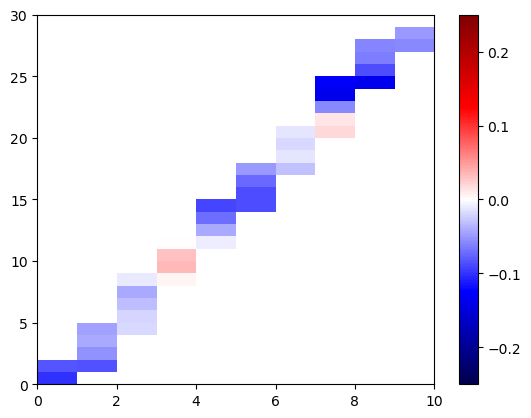

In [84]:
plt.pcolormesh(np.where(mask, u, np.nan),vmin=-.25, vmax=.25, cmap = 'seismic')
plt.colorbar()

In [85]:
v = ds_v4['vomecrty'][0, 0, 180:210, 310:320]

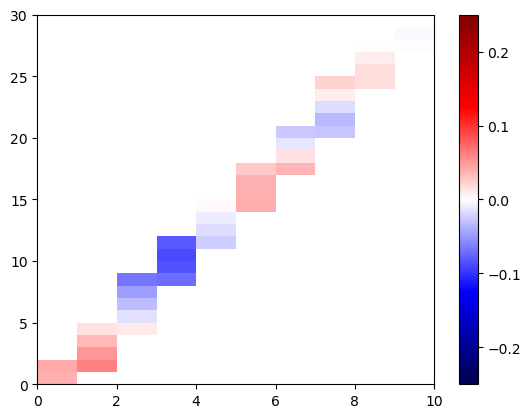

In [87]:
plt.pcolormesh(np.where(mask, v, np.nan),vmin=-.25, vmax=.25, cmap = 'seismic')
plt.colorbar()